# Tutorial 03: The TreeNN Encoder

In the previous tutorials, we looked at how search trees are sampled and flattened into tensors. Now, we dive into the **Compute**: how the GNN actually processes these trees to predict the "Oracle Truth."

### Mechanistic Truth: The Two-Phase Round
A single round (k=1) of the GNN is NOT a single pass. It consists of **two distinct, sequential phases**, each with its own internal update logic.

In [1]:
import os
import sys
from pathlib import Path
import torch
import chess
import numpy as np

# Setup Path
os.environ["PATH"] += os.pathsep + "/opt/homebrew/bin"
LMCOS_DIR = Path(os.getcwd()).parent
if str(LMCOS_DIR) not in sys.path:
    sys.path.insert(0, str(LMCOS_DIR))

from helper_gnn import visualize_upward_step, visualize_downward_step, visualize_dual_pass
from helper_tensorization import plot_tree, summarize_batch_structure, visualize_batch_layout
from tree import SearchTree, ExpansionChild
from schema import tree_encoder_feature_schema, TREE_ENCODER_FEATURE_NAMES
from tensorizer import TreeTensorizer
from GNN import TreeNN

## Phase 0: The Input Tree & Tensorization

We start with a simple fork: Parent $\to$ Child 1, Child 2. 

### 1. High-Level View
First, we build the tree and generate the **Initial Embeddings** ($h_0$) for every node.

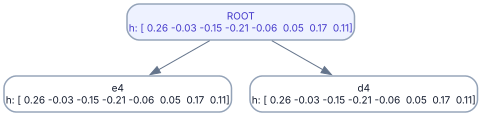

In [2]:
t = SearchTree()
static = {f: 0.5 for f in TREE_ENCODER_FEATURE_NAMES}
t.create_root(chess.STARTING_FEN, static)
t.add_children(0, [
    ExpansionChild("e4", "FEN_E4", static), 
    ExpansionChild("d4", "FEN_D4", static)
])

# Tensorize and build GNN to generate h_0
schema = tree_encoder_feature_schema()
tensorizer = TreeTensorizer(schema)
batch = tensorizer.tensorize_forest([t])
gnn = TreeNN(k=1, node_feat=5, device='cpu', node_embed_hidden=64, d_embed=8, n_heads=1)
h_0 = gnn.node_embed(batch.node_features.to('cpu'))

display(plot_tree(t, "Tree with Initial Embeddings (h0)", node_data={i: h_0[i] for i in range(3)}))

### 2. "Under the Hood" (Folded Layout)
Recall from Tutorial 02 that the GNN doesn't actually see graphs. It sees these flat vectors and indices. This is the **actual memory layout** during the compute round.

--- FOLDED REPRESENTATION ---
Total Nodes in Batch: 3
Batch Size (Trees):   1

--- ENCODING THE HIERARCHY ---
Depth Vector:  [0, 1, 1]
Parent Index: [-1, 0, 0]
Edge Slots:   [0, 1]
  (Note: -1 means the node is a Root)
Root Indices: [0]


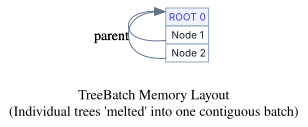

In [3]:
summarize_batch_structure(batch)
display(visualize_batch_layout(batch))

## Phase 1: Upward Sweep (The Summary)

Information from the children is pooled via **Multi-Head Attention** and integrated into the Parent.

PHASE 1 VISUAL (Parent Updated, Children Fixed)


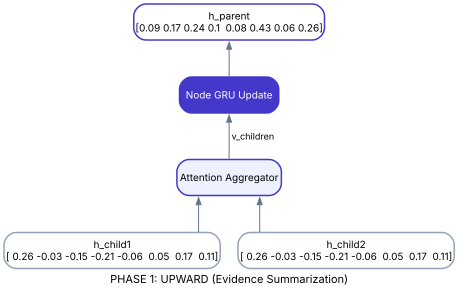

In [4]:
h_1 = h_0.clone()
edge_parent = batch.edge_parent
edge_child = batch.edge_child
edge_slot_embed = gnn.slot_embeddings(batch.edge_slot)

upward = gnn.upward_msg(h_1, edge_parent, edge_child, edge_slot_embed=edge_slot_embed)
h_1[0:1] = gnn.node_gru(upward[0:1], h_1[0:1]) 

print("PHASE 1 VISUAL (Parent Updated, Children Fixed)")
display(visualize_upward_step(h_parent=h_1[0], h_c1=h_1[1], h_c2=h_1[2]))

## Phase 2: Downward Sweep (The Context)

The Parent summary is now broadcast back to every child to provide global strategy context.

PHASE 2 VISUAL (Everything Synchronized)


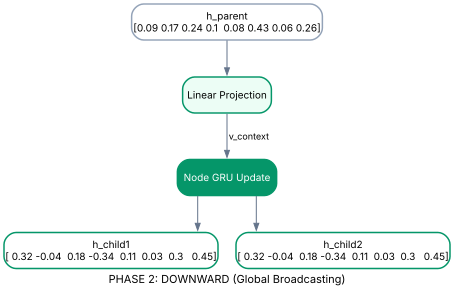

In [5]:
h_2 = h_1.clone()
msg_for_kids = gnn.downward_msg(h_2[edge_parent]) 
h_2[1:3] = gnn.node_gru(msg_for_kids, h_2[1:3]) 

print("PHASE 2 VISUAL (Everything Synchronized)")
display(visualize_downward_step(h_parent=h_2[0], h_c1=h_2[1], h_c2=h_2[2]))

## Conclusion: Final Synchronization

Notice how by the end of Phase 2, the actual floating point values in the diagram have evolved. The Child modules now contain vectors that have "seen" their Parent.

FULL ROUND SUMMARY (Before -> After Data Transition)


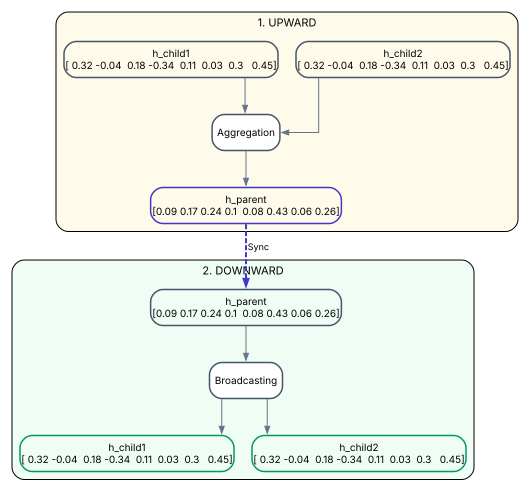

In [6]:
print("FULL ROUND SUMMARY (Before -> After Data Transition)")
display(visualize_dual_pass(h_parent=h_2[0], h_c1=h_2[1], h_c2=h_2[2]))